In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder

df['Gender'] = LabelEncoder().fit_transform(df['Gender'])
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
...,...,...,...,...,...
395,15691863,0,46,41000,1
396,15706071,1,51,23000,1
397,15654296,0,50,20000,1
398,15755018,1,36,33000,0


In [7]:
X = df.drop(columns = ['User ID', 'Purchased'])
Y = df['Purchased']

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
model = LogisticRegression()
model.fit(X_train_scaled, Y_train)

LogisticRegression()

In [12]:
y_pred = model.predict(X_test_scaled)

In [17]:
cm = confusion_matrix(Y_test,y_pred)
print(cm)
TP = cm[1][1]
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
print('True Positives:', TP)
print('True Negatives:', TN)
print('False Positives:', FP)
print('False Negatives:', FN)

[[50  2]
 [ 7 21]]
True Positives: 21
True Negatives: 50
False Positives: 2
False Negatives: 7


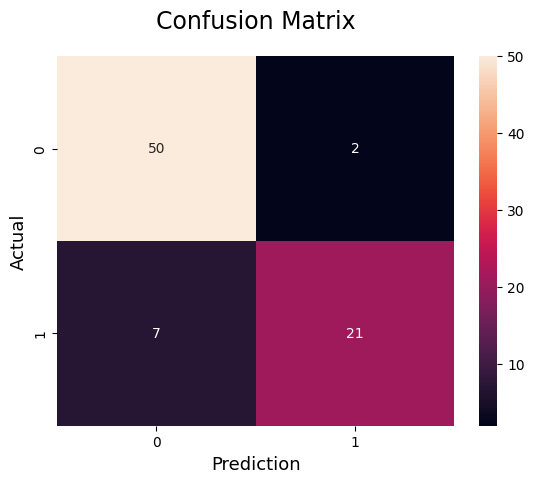

In [16]:
sns.heatmap(cm, annot=True)
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Prediction', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.show()

In [19]:
# confusion_matrix → 2x2 array showing TP, TN, FP, FN

# accuracy_score → (TP + TN) / Total

# precision_score → TP / (TP + FP) → how many predicted positives were actually correct

# recall_score → TP / (TP + FN) → how many actual positives were correctly found

# Accuracy
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(Y_test, y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(Y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.8875
Precision: 0.9130434782608695
Recall: 0.75


In [20]:
# Accuracy: 0.8875 →
# This means 88.75% of your model’s predictions were correct (both positives and negatives).
# It's a good general performance metric, but it doesn’t tell the whole story.

# Precision: 0.913 →
# Out of all the passengers your model predicted as "will purchase" (class 1),
# 91.3% were actually correct.

#     High precision = low false positives.

# Recall: 0.75 →
# Out of all actual "purchasers", your model correctly found 75% of them.

#     This means your model missed 25% (false negatives) of the true positive cases.